In [163]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random
import os
import math

In [235]:
class FakeMinimapGenerator():
    def __init__(self):
        self.assets = {}
        self.champion_names = os.listdir('league_icons/champions')

    def load_image(self, path):
        if path in self.assets:
            return self.assets[path]
        else:
            image = cv2.imread(path, cv2.IMREAD_UNCHANGED)
            self.assets[path] = image
            return self.assets[path]
    
    def place_vision(self, lightmap, cx, cy, r):
        h, w, _ = lightmap.shape
        mask = np.ones((h, w), np.float32)
        cv2.circle(mask, (cx, cy), r, 3.0, -1)
        mask = cv2.GaussianBlur(mask, (0, 0), sigmaX=1)
        mask = mask[..., None]
        lightmap = np.maximum(lightmap, mask)
        return lightmap
    
    def place_image(self, base, img, x, y):
        base_h, base_w = base.shape[:2]
        img_h, img_w = img.shape[:2]
        x1 = max(x, 0)
        y1 = max(y, 0)
        x2 = min(x + img_w, base_w)
        y2 = min(y + img_h, base_h)
    
        # No overlap
        if x1 >= x2 or y1 >= y2:
            return base
    
        # Corresponding region in overlay
        img_x1 = x1 - x
        img_y1 = y1 - y
        img_x2 = img_x1 + (x2 - x1)
        img_y2 = img_y1 + (y2 - y1)
    
        # Convert to float
        base = base.astype(np.float32)
        img = img.astype(np.float32)
    
        # Extract alpha and expand dims
        alpha = img[img_y1:img_y2, img_x1:img_x2, 3] / 255.0
        alpha = alpha[..., None]
    
        # Blend
        base[y1:y2, x1:x2, :] = (
            base[y1:y2, x1:x2, :] * (1 - alpha) +
            img[img_y1:img_y2, img_x1:img_x2, :3] * alpha
        )
    
        return base.astype(np.uint8)
        
    def generate_background(self):
        base_image_name = random.choice(os.listdir('league_icons/minimap/base'))
        base = self.load_image(f'league_icons/minimap/base/{base_image_name}')
        base[:, :, 3] //= 3
        blackboard = np.zeros(shape=[base.shape[0], base.shape[1], 3])
        base = self.place_image(blackboard, base, 0, 0)
        do_atackan_overlay = random.randint(0, 1) == 1
        if do_atackan_overlay:
            overlay_image_name = random.choice(os.listdir('league_icons/minimap/overlay'))
            overlay_image = self.load_image(f'league_icons/minimap/overlay/{overlay_image_name}')
            base = self.place_image(base, overlay_image, 0, 0)
        return base

    def draw_shops(self, base):
        shop_icon = self.load_image('league_icons/misc/shop.png')
        shop_icon = cv2.resize(shop_icon,  None, fx=0.7, fy=0.7)
        base = self.place_image(base, shop_icon, -10, 225)
        base = self.place_image(base, shop_icon, 225, -7)
        return base
        
    def draw_wave(self, base, lightmap, start_coord, end_coord, center_coord, travel_distance, enemy_minion):
        minion_icon_path = 'league_icons/misc/minionmapcircle_enemy.png' if enemy_minion else 'league_icons/misc/minionmapcircle_ally.png'
        minion_icon = self.load_image(minion_icon_path)
        minion_icon = cv2.resize(minion_icon, None, fx=0.7, fy=0.7)
        minion_icon[:, :, :3] //= 3
        
        if enemy_minion:
            start_coord[0] = 255 - start_coord[0]
            start_coord[1] = 255 - start_coord[1]
            center_coord[0] = 255 - center_coord[0]
            center_coord[1] = 255 - center_coord[1]
            end_coord[0] = 255 - end_coord[0]
            end_coord[1] = 255 - end_coord[1]
            
        start_x = start_coord[0] * (1 - travel_distance) + end_coord[0] * travel_distance
        start_y = start_coord[1] * (1 - travel_distance) + end_coord[1] * travel_distance

        if travel_distance > 0.8:
            target_coord = center_coord
        else:
            target_coord = end_coord

        m = math.sqrt((start_x - target_coord[0]) ** 2 + (start_y - target_coord[1]) ** 2)
        dx = (target_coord[0] - start_x) / m
        dy = (target_coord[1] - start_y) / m

        dx *= 5
        dy *= 5
        
        for _ in range(6):
            base = self.place_image(base, minion_icon, int(start_x), int(start_y))
            lightmap = self.place_vision(lightmap, int(start_x), int(start_y), 15)
            start_x += dx
            start_y += dy
        return base, lightmap
        
    def draw_minions(self, base, lightmap):
        wave_progress = random.random() * 0.9
        base, lightmap = self.draw_wave(base, lightmap, [20, 215], [20, 35], [35, 35], wave_progress, True)
        base, lightmap = self.draw_wave(base, lightmap, [35, 215], [104, 154], [127, 127], wave_progress, True)
        base, lightmap = self.draw_wave(base, lightmap, [41, 232], [202, 235], [215, 215], wave_progress, True)
        base, lightmap = self.draw_wave(base, lightmap, [20, 215], [20, 35], [35, 35], wave_progress, False)
        base, lightmap = self.draw_wave(base, lightmap, [35, 215], [104, 154], [127, 127], wave_progress, False)
        base, lightmap = self.draw_wave(base, lightmap, [41, 232], [202, 235], [215, 215], wave_progress, False)
        return base, lightmap

    def draw_tower(self, base, lightmap, x, y, enemy_tower, level, destruction):
        if random.randint(0, 1) == 1:
            return base, lightmap
        if level > 0:
            tower_icon_path = f'league_icons/misc/icon_ui_tower_minimap_{level}_palisades.png'
        else:
            if destruction == 0:
                tower_icon_path = 'league_icons/misc/tower.png'
            elif destruction == 1:
                tower_icon_path = 'league_icons/misc/tower_medium.png'
            elif destruction == 2:
                tower_icon_path = 'league_icons/misc/tower_low.png'
        tower_icon = self.load_image(tower_icon_path)
        if level > 0:
            tower_icon = cv2.resize(tower_icon, None, fx=0.4, fy=0.4)
        else:
            tower_icon = cv2.resize(tower_icon, None, fx=0.25, fy=0.25)
        tower_icon = tower_icon.astype(np.float32)
        if enemy_tower:
            color_factor = np.array([4.068, 4.068, 1.112], dtype=np.float32)
        else:
            color_factor = np.array([1, 1.227, 3.56], dtype=np.float32)
        tower_icon[:, :, :3] /= color_factor
        tower_icon[:, :, :3] /= 3
        tower_icon = np.clip(tower_icon, 0, 255).astype(np.uint8)

        base = self.place_image(base, tower_icon, x, y)
        lightmap = self.place_vision(lightmap, x+8, y+8, 25)
        
        return base, lightmap

    def draw_towers(self, base, lightmap):
        base, lightmap = self.draw_tower(base, lightmap, 9, 66, False, random.randint(1, 5), 0)
        base, lightmap = self.draw_tower(base, lightmap, 18, 132, False, 0, random.randint(0, 2))
        base, lightmap = self.draw_tower(base, lightmap, 12, 175, False, 0, random.randint(0, 2))

        base, lightmap = self.draw_tower(base, lightmap, 92, 136, False, random.randint(1, 5), 0)
        base, lightmap = self.draw_tower(base, lightmap, 80, 165, False, 0, random.randint(0, 2))
        base, lightmap = self.draw_tower(base, lightmap, 55, 185, False, 0, random.randint(0, 2))

        base, lightmap = self.draw_tower(base, lightmap, 66, 228, False, 0, 0)
        base, lightmap = self.draw_tower(base, lightmap, 112, 223, False, 0, random.randint(0, 2))
        base, lightmap = self.draw_tower(base, lightmap, 173, 229, False, 5, random.randint(0, 2))
        
        base, lightmap = self.draw_tower(base, lightmap, 65, 5, True, random.randint(1, 5), 0)
        base, lightmap = self.draw_tower(base, lightmap, 130, 15, True, 0, random.randint(0, 2))
        base, lightmap = self.draw_tower(base, lightmap, 174, 11, True, 0, random.randint(0, 2))

        base, lightmap = self.draw_tower(base, lightmap, 146, 99, True, random.randint(1, 5), 0)
        base, lightmap = self.draw_tower(base, lightmap, 162, 73, True, 0, random.randint(0, 2))
        base, lightmap = self.draw_tower(base, lightmap, 186, 53, True, 0, random.randint(0, 2))

        base, lightmap = self.draw_tower(base, lightmap, 231, 168, True, random.randint(1, 5), 0)
        base, lightmap = self.draw_tower(base, lightmap, 222, 106, True, 0, random.randint(0, 2))
        base, lightmap = self.draw_tower(base, lightmap, 229, 65, True, 0, random.randint(0, 2))
        return base, lightmap

    def draw_wards(self, base, lightmap):
        num_wards = random.randint(2, 15)

        ward_names = ['minimap_ward_blue.png', 'minimap_ward_green.png', 'minimap_ward_green_enemy.png', 'minimap_ward_green_low.png', 'minimap_ward_pink_enemy.png', 'minimap_ward_pink_friendly.png', 'minimap_jammer_enemy.png', 'minimap_jammer_friendly.png']

        weights = [10, 10, 10, 5, 3, 3, 1, 1]

        ward_names = random.choices(ward_names, weights, k=num_wards)
        
        for w in ward_names:
            ward_icon = self.load_image(f'league_icons/misc/{w}')
            size = 0.5 + random.random() * 0.2
            ward_icon = cv2.resize(ward_icon, None, fx=size, fy=size)
            ward_icon[:, :, :3] //= 3
            x = random.randint(0, 255-32)
            y = random.randint(0, 255-32)
            base = self.place_image(base, ward_icon, x, y)
            lightmap = self.place_vision(lightmap, x + 8, y + 8, 20)
        return base, lightmap

    def draw_champions(self, base, lightmap):
        for _ in range(10):
            x = random.randint(0, 255-26)
            y = random.randint(0, 255-26)
            random_champion_name = random.choice(self.champion_names)
            champion_icon = self.load_image(f'league_icons/champions/{random_champion_name}')
            champion_icon = cv2.resize(champion_icon, [24, 24])
            champion_icon[:, :, :3] //= 3
            if random.randint(0, 1) == 1:
                cv2.circle(base, [x+14, y+14], 13, [61 // 3, 61 // 3, 232 // 3], -1, lineType=cv2.LINE_AA)
            else:
                cv2.circle(base, [x+14, y+14], 13, [224 // 3, 153 // 3, 0 // 3], -1, lineType=cv2.LINE_AA)
            base = self.place_image(base, champion_icon, x+2, y+2)
            lightmap = self.place_vision(lightmap, x+13+random.randint(-5, 5), y+13+random.randint(-5, 5), 20)
        return base, lightmap
        
    def generate(self):
        base = self.generate_background()
        h, w, _ = base.shape
        lightmap = np.ones(shape=[h, w, 1]).astype(np.float32)
        base, lightmap = self.draw_minions(base, lightmap)
        base, lightmap = self.draw_towers(base, lightmap)
        base, lightmap = self.draw_wards(base, lightmap)
        base, lightmap = self.draw_champions(base, lightmap)

        base = np.clip((base * lightmap), 0, 255).astype(np.uint8)
        
        # draw plants
        # draw pings
        # draw camera
        # draw jungle camps
        base = self.draw_shops(base)
        
        return cv2.cvtColor(base, cv2.COLOR_BGR2RGB)

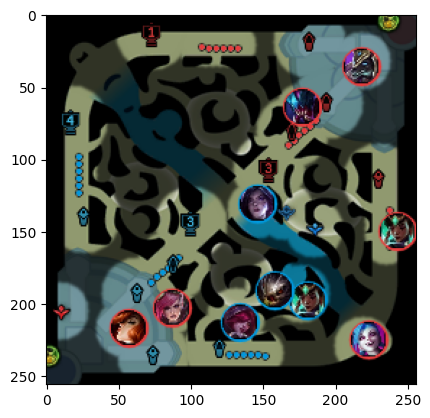

In [237]:
generator = FakeMinimapGenerator()
img = generator.generate()
plt.imshow(img)